In [2]:
import requests, zipfile
import io
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [ ]:
url = 'http://archive.ics.uci.edu/m1/machine-learnig-datasets/mushroom/agaricis-lepiota.data'
res = requests.get(url).content

mushroom = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)

mushroom.columns = ['classes','cap_shape', 'cap_surface', 'cap_color', 'odor', 'bruises',
                               'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color', 'stalk_shape',
                               'stalk_root', 'stalk_surface_above_ring', 'stalk_surface_below_ring', 'stalk_color_above_ring', 'stalk_color_below_ring',
                               'veil_type', 'veil_color', 'ring_number', 'ring_type', 'spore_print_color', 'population', 'habitat']
mushroom.head()

In [ ]:
# Practice 8-5
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'
res = requests.get(url).content

auto = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None, sep=',')
auto.columns = ['symboling', 'normalized-losses','make','fuel-type','aspiration','num-of-doors',
                'body-style','drive-wheels','engine-location','wheel-base','length','width','height',
                'curb-weight','engine-type','num-of-cylinders','engine-size','fuel-system','bore',
                'stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price']






In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.3, random_state=0)

models ={
    'tree1' : DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0),
    'tree2' : DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0),
    'tree3' : DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=0),
    'tree4' : DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0),
    'tree5' : DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=0),
    'tree6' : DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=0)}


score = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    score[model_name, 'test'] = model.score(X_test, y_test)
    score[model_name, 'train'] = model.score(X_train, y_train)

pd.Series(score).unstack()

,test,train
tree1,0.953216,0.964824
tree2,0.935673,0.992462
tree3,0.935673,1.000000
tree4,0.947368,0.967337
tree5,0.935673,0.987437
tree6,0.912281,1.000000


In [ ]:
# Practice 8-7
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip'
# getはデータをくださいという意味
r = requests.get(url, stream=True)

#zipファイルの読み込み展開する
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

In [ ]:
student = pd.read_csv('student-mat.csv', sep=';')

X = student.loc[:, ['age', 'Medu', 'Fedu', 'traveltime', 'studytime',
                'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
                'absences', 'G1', 'G2']].values



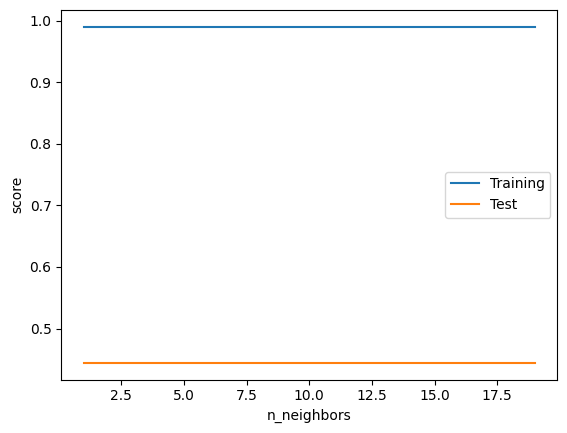

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, student.G3, random_state=0)

training_accuracy = []
test_accuracy = []

#training_score = []
#test_score = []

for n_neighbors in range(1,20):
  mdoel = KNeighborsRegressor(n_neighbors=n_neighbors)
  model.fit(X_train, y_train)
  training_accuracy.append(model.score(X_train, y_train))
  test_accuracy.append(model.score(X_test, y_test))


plt.plot(range(1,20), training_accuracy, label='Training')
plt.plot(range(1,20), test_accuracy, label='Test')
plt.xlabel('n_neighbors')
plt.ylabel('score')
plt.legend()



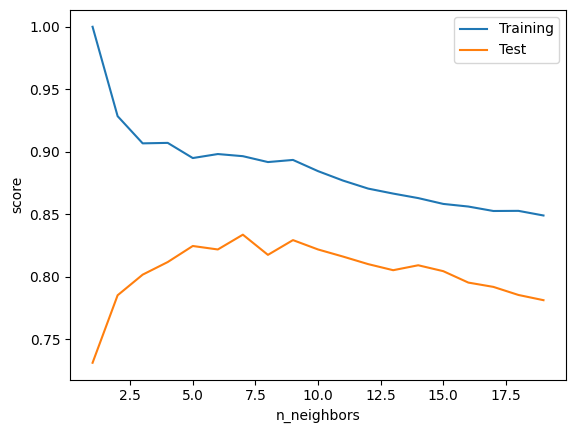

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, student.G3, random_state=0)

training_accuracy = []
test_accuracy = []

training_score = []
test_score = []
neighbors_settings = range(1,20)

for n_neighbors in neighbors_settings:
  model = KNeighborsRegressor(n_neighbors=n_neighbors)
  model.fit(X_train, y_train)
  training_score.append(model.score(X_train, y_train))
  test_score.append(model.score(X_test, y_test))


plt.plot(neighbors_settings, training_score, label='Training')
plt.plot(neighbors_settings, test_score, label='Test')
plt.ylabel('score')
plt.xlabel('n_neighbors')
plt.legend()

回帰：与えられた入力変数（特徴量）に基づいて、出力変数（目的変数）の連続値を予測することです。回帰モデルは、入力と出力の間の関係を学習し、新しいデータが与えられたときに適切な予測を行うこと

分類 : 分類の目的は、入力データがどのカテゴリに属するかを予測することです。分類モデルは、入力データ（特徴量）と対応するカテゴリ（ラベル）との関係を学習し、新しいデータが与えられたときにそのカテゴリを予測を行う

教師有り学習 :過去の(訓練)データを用いた予想モデルの構築や分類を役割とし、精度の向上などを目的としている。

重回帰分析 : 予測と各独立変数のデータ内の関係性を明らかにする。

情報利得 : 情報利得は、ある特徴量によってデータセットがどれだけ「純度」（混乱度）が改善されるかを測定する。情報利得が高いほど、特徴量はデータの分類に有用であることを示す。

エントロピー :データセットの不確実性や混乱度を測定する尺度。高いほど、データは混在しており、予測が難しいことを示す。

k-NN法 : 入力データの特徴量空間内で「最も近い」k個のデータ点（最近傍）のラベルや値を参照して、新しいデータ点のラベルや値を予測する。

SVM : 高次元のデータや線形分離可能なデータに対して効果的です。SVMは、データポイントを異なるクラスに分類するための最適な境界（ハイパープレーン）を見つけることを目的としている。

ノーフリーランチ : どのアルゴリズムも全ての問題に対して一貫して優れているわけではないということを示している。

In [ ]:
# Cm8-2
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, stratify=iris.target, random_state=0)

model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
model.fit(X_train, y_train)

print('正解率(train):{:.3f}'.format(model.score(X_train, y_train)))
print('正解率(test):{:.3f}'.format(model.score(X_test, y_test)))



正解率(train):0.964
正解率(test):0.947


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.3, random_state=0)

models ={
    'forest1' : RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=3, random_state=0),
    'forest2' : RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=5, random_state=0),
    'forest3' : RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=10, random_state=0),
    'forest4' : RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=3, random_state=0),
    'forest5' : RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=5, random_state=0),
    'forest6' : RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=10, random_state=0)}

score = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    score[model_name, 'test'] = model.score(X_test, y_test)
    score[model_name, 'train'] = model.score(X_train, y_train)

# Display the scores in a DataFrame
score_df = pd.Series(score).unstack()
print(score_df)


             test     train
forest1  0.941520  0.977387
forest2  0.970760  0.994975
forest3  0.959064  1.000000
forest4  0.953216  0.979899
forest5  0.959064  0.992462
forest6  0.959064  1.000000
